# **1. Perkenalan Dataset**


The bank customer churn dataset is a commonly used dataset for predicting customer churn in the banking industry. It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

Customer ID: A unique identifier for each customer  
Surname: The customer's surname or last name  
Credit Score: A numerical value representing the customer's credit score  
Geography: The country where the customer resides (France, Spain or Germany)  
Gender: The customer's gender (Male or Female)  
Age: The customer's age.  
Tenure: The number of years the customer has been with the bank  
Balance: The customer's account balance  
NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)  
HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)  
IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)  
EstimatedSalary: The estimated salary of the customer  
Exited: Whether the customer has churned (1 = yes, 0 = no)  

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from joblib import dump


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# load dataset
df = pd.read_csv("../bank_customer.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## Cek Struktur Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


## Cek Statistik Data


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10002.000000,1.000200e+04,10002.000000,10001.000000,10002.000000,10002.000000,10002.000000,10001.000000,10001.000000,10002.000000,10002.000000
mean,5001.499600,1.569093e+07,650.555089,38.922311,5.012498,76491.112875,1.530194,0.705529,0.514949,100083.331145,0.203759
std,2887.472338,7.193177e+04,96.661615,10.487200,2.891973,62393.474144,0.581639,0.455827,0.499801,57508.117802,0.402812
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2501.250000,1.562852e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50983.750000,0.000000
50%,5001.500000,1.569073e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,1.000000,100185.240000,0.000000
75%,7501.750000,1.575323e+07,718.000000,44.000000,7.000000,127647.840000,2.000000,1.000000,1.000000,149383.652500,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


## Visualisasi Data Churn Customer

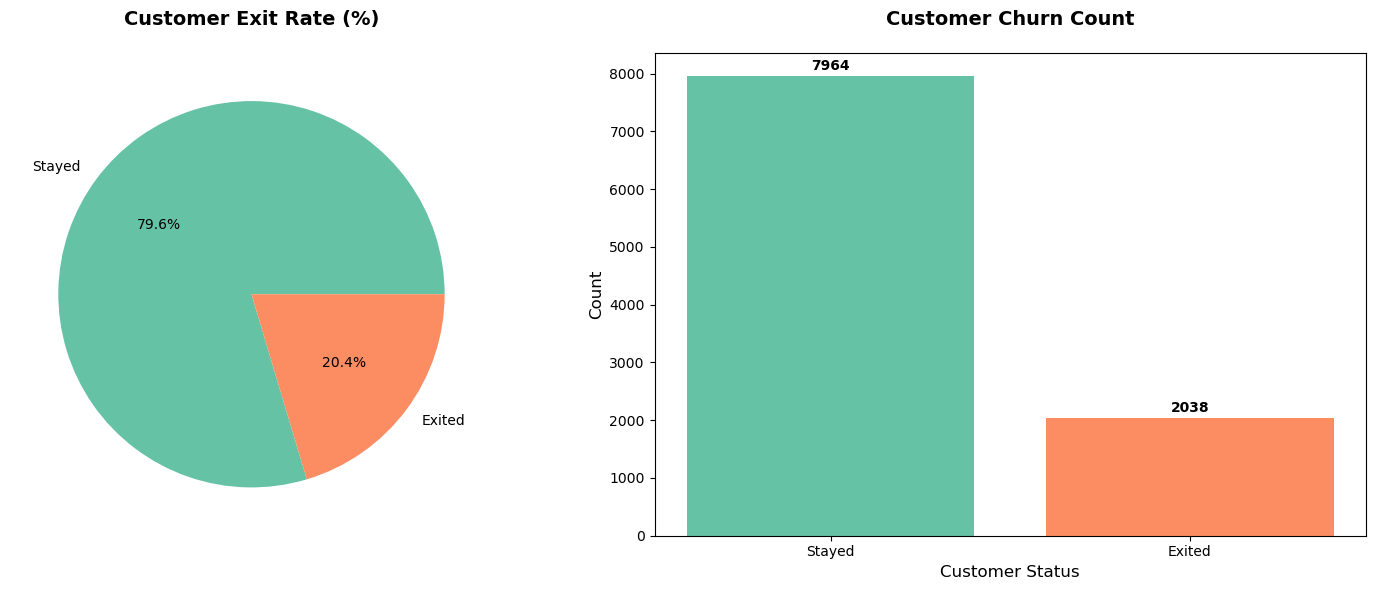

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Data untuk visualisasi
churn_counts = df["Exited"].value_counts()
churn_rate = df["Exited"].value_counts() / len(df) * 100
labels = ["Stayed", "Exited"]
colors = sns.color_palette("Set2", 2)

# Subplot 1: Pie Chart
ax1.pie(
    churn_rate,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
)
ax1.set_title("Customer Exit Rate (%)", fontsize=14, fontweight="bold", pad=20)

# Subplot 2: Bar Chart
bars = ax2.bar(
    labels,
    churn_counts.values,
    color=colors,
    linewidth=1.2,
)
ax2.set_title("Customer Churn Count", fontsize=14, fontweight="bold", pad=20)
ax2.set_xlabel("Customer Status", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)

# Menambahkan label pada bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 50,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Menyesuaikan layout
plt.tight_layout()
plt.show()

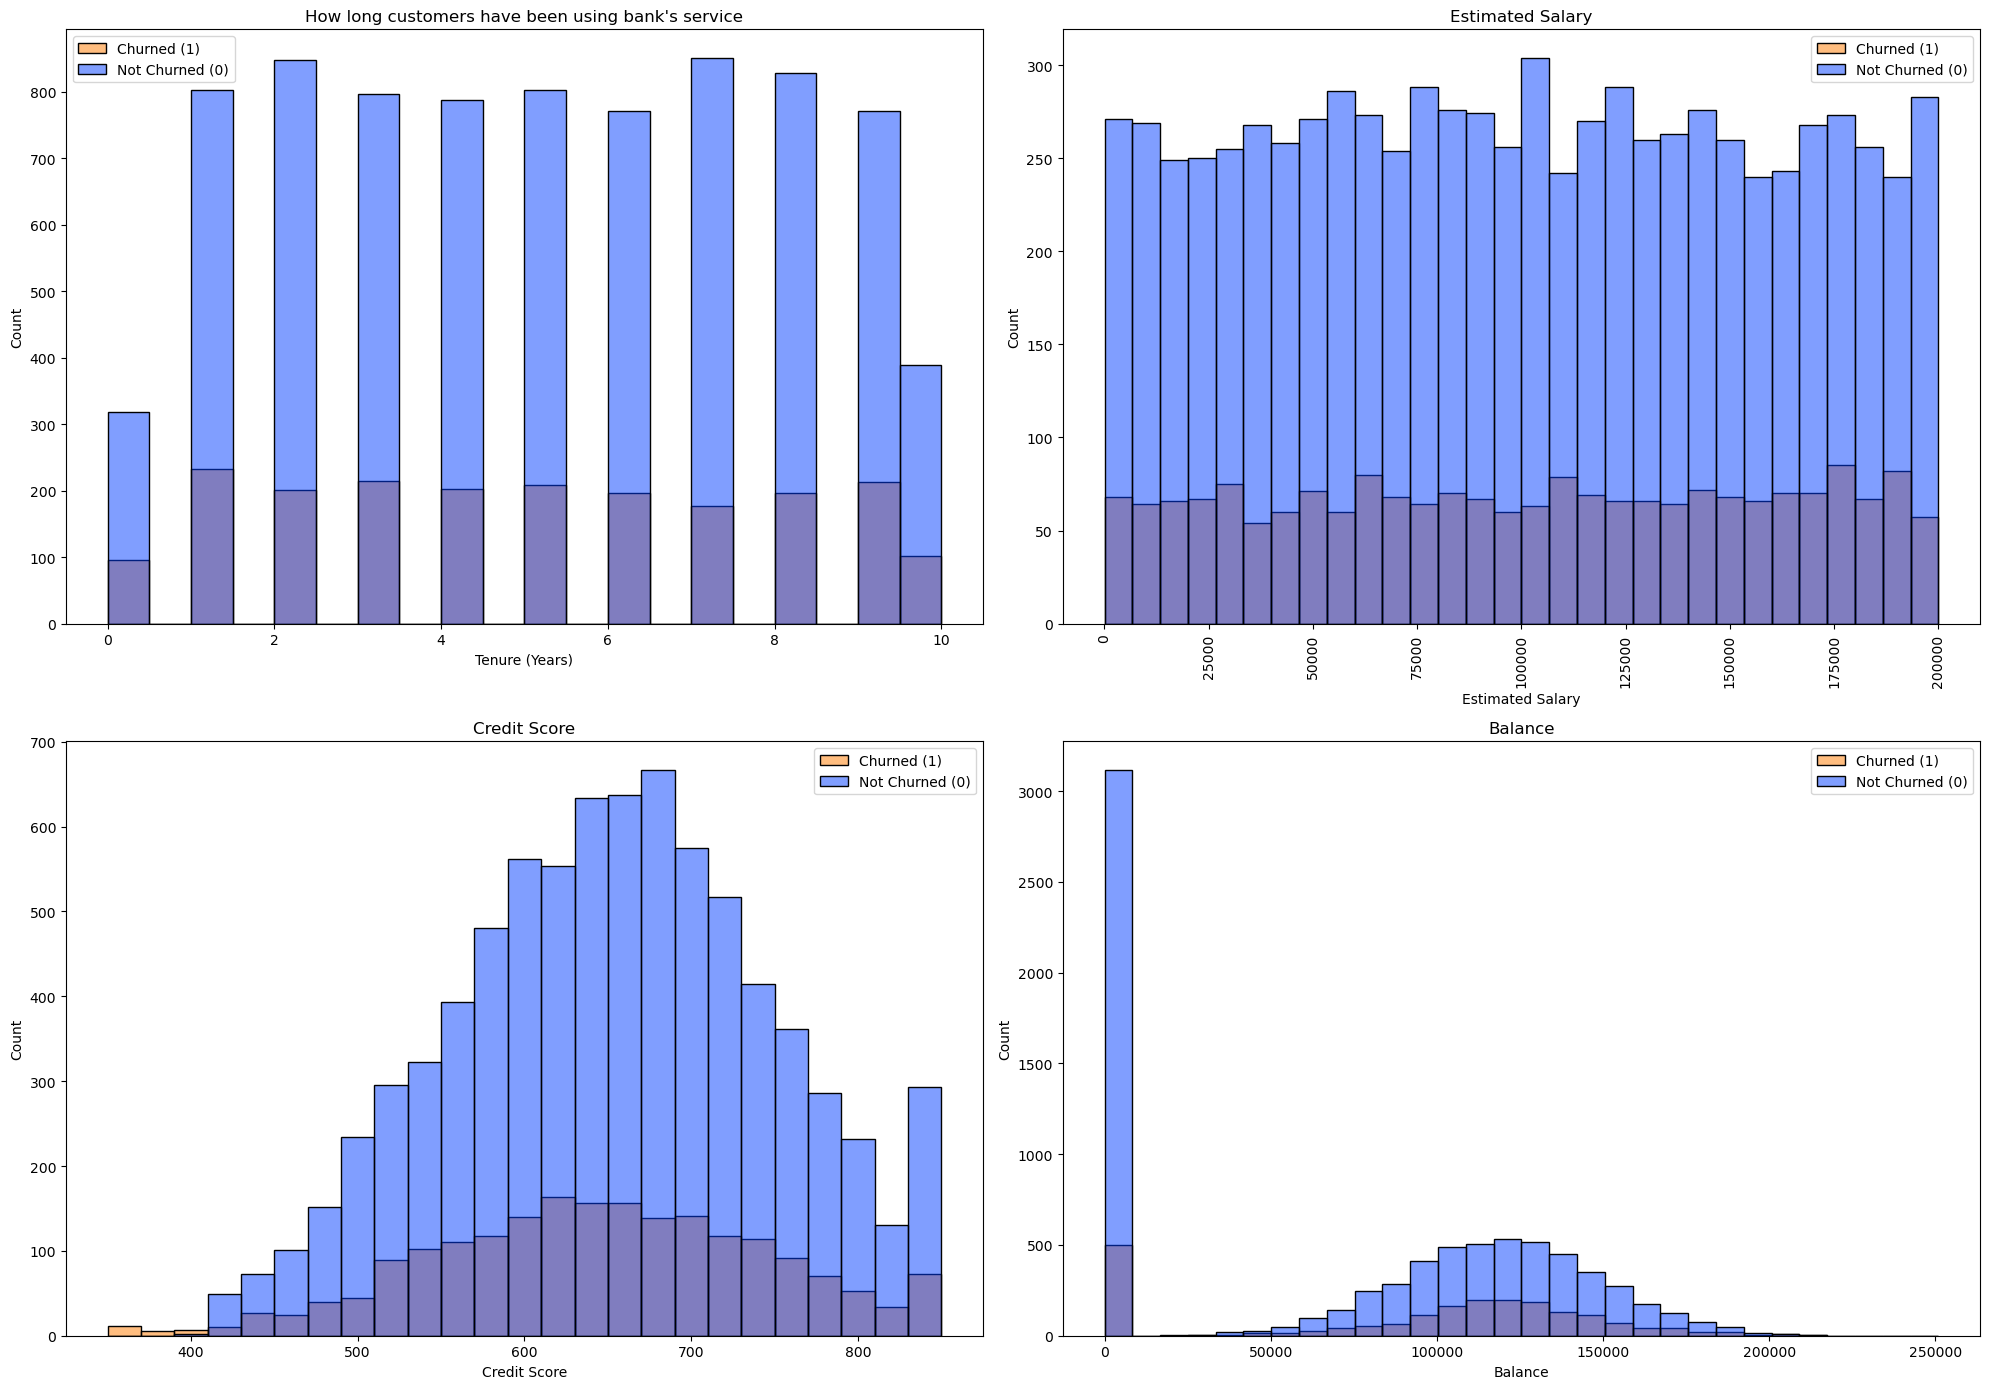

In [6]:
# Visualisasi Kolom Numerik
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Konfigurasi untuk setiap subplot
plots_config = [
    {
        "col": "Tenure",
        "bins": 20,
        "title": "How long customers have been using bank's service",
        "xlabel": "Tenure (Years)",
        "rotate": False,
    },
    {
        "col": "EstimatedSalary",
        "bins": 30,
        "title": "Estimated Salary",
        "xlabel": "Estimated Salary",
        "rotate": True,
    },
    {
        "col": "CreditScore",
        "bins": 25,
        "title": "Credit Score",
        "xlabel": "Credit Score",
        "rotate": False,
    },
    {
        "col": "Balance",
        "bins": 30,
        "title": "Balance",
        "xlabel": "Balance",
        "rotate": False,
    },
]

for ax, config in zip(axes.flat, plots_config):
    sns.histplot(
        x=config["col"],
        data=df,
        bins=config["bins"],
        hue="Exited",
        palette="bright",
        ax=ax,
    )
    ax.set_title(config["title"])
    ax.set_xlabel(config["xlabel"])
    ax.set_ylabel("Count")
    ax.legend(labels=["Churned (1)", "Not Churned (0)"])
    if config["rotate"]:
        ax.tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()

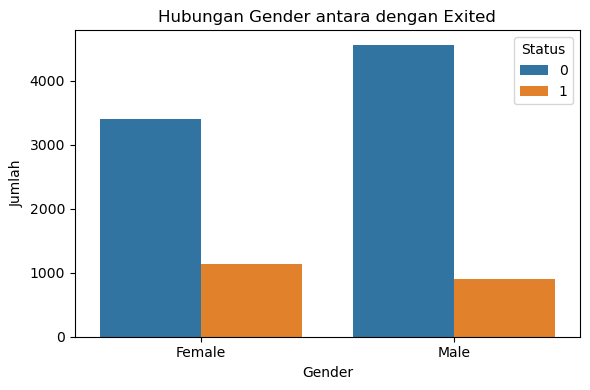

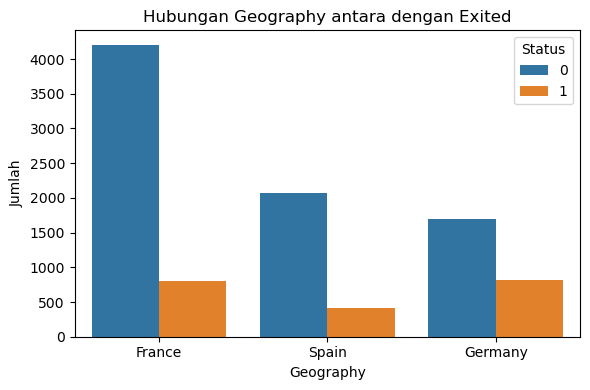

In [7]:
# categorical columns
categorical_cols = [
    "Gender",
    "Geography",
]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue="Exited")
    plt.title(f"Hubungan {col} antara dengan Exited")
    plt.ylabel("Jumlah")
    plt.legend(title="Status")
    plt.tight_layout()
    plt.show()

## Korelasi Antar Fitur

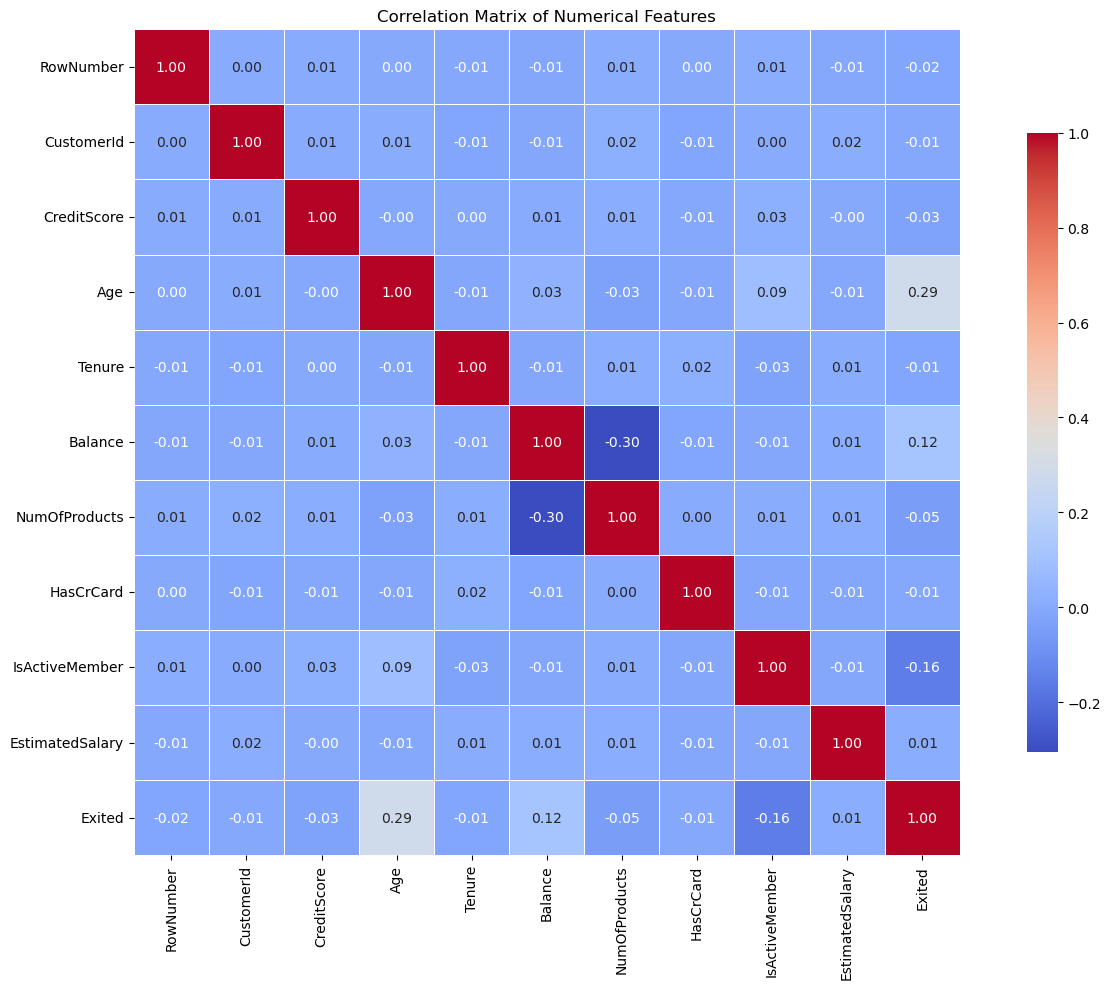

In [8]:
df_new = df.copy()
df_numeric = df_new.select_dtypes(include=["int64", "float64"])

# Hitung korelasi Pearson
corr_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Distribusi Data

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## Cek Missing Value

In [9]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
# Drop missing value
df = df.dropna()
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Cek Data Duplikat

In [11]:
# cek data duplikat
print(f"Jumlah Data Duplikat : {df.duplicated().sum()}")

Jumlah Data Duplikat : 2


In [12]:
# Hapus data duplikat
df = df.drop_duplicates()
print(f"Jumlah Data Duplikat : {df.duplicated().sum()}")

Jumlah Data Duplikat : 0


## Drop Kolom Tidak Relevan

In [13]:
# Drop irrelevant columns
df_new = df.copy()
df_new = df_new.drop(columns=["RowNumber", "CustomerId", "Surname"])
df_new.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1


## Encoding Data Kategorikal

In [14]:
# Inisialisasi LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encoding kolom kategorikal
df_new["Geography"] = le.fit_transform(df_new["Geography"])
df_new["Gender"] = le.fit_transform(df_new["Gender"])
df_new.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,608,2,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,502,0,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,699,0,0,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,645,2,1,44.0,8,113755.78,2,1.0,0.0,149756.71,1


##  Data Standarization

In [15]:
# Pilih Kolom Numerikal
df_numeric = df_new.select_dtypes(include=["int64", "float64", "int32"])
df_numeric = df_numeric.drop(columns="Exited")
df_numeric.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42.0,2,0.00,1,1.0,1.0,101348.88
1,608,2,0,41.0,1,83807.86,1,0.0,1.0,112542.58
2,502,0,0,42.0,8,159660.80,3,1.0,0.0,113931.57
3,699,0,0,39.0,1,0.00,2,0.0,0.0,93826.63
5,645,2,1,44.0,8,113755.78,2,1.0,0.0,149756.71


In [16]:
# Lakukan standarisasi
scaler = StandardScaler()
df_numeric_scaled = scaler.fit_transform(df_numeric)
# Buat DataFrame hasil standarisasi dengan kolom yang sama
df_scaled = pd.DataFrame(df_numeric_scaled, columns=df_numeric.columns)
# Gabungkan dengan kolom non-numerik atau kolom target jika perlu
df_final = pd.concat([df_scaled, df[["Exited"]].reset_index(drop=True)], axis=1)
df_final.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,-0.326054,-0.902039,-1.095807,0.293570,-1.041870,-1.225699,-0.911557,0.646119,0.970619,0.021599,1
1,-0.439902,1.515004,-1.095807,0.198222,-1.387627,0.117505,-0.911557,-1.547702,0.970619,0.216237,0
2,-1.536986,-0.902039,-1.095807,0.293570,1.032669,1.333214,2.526905,0.646119,-1.030270,0.240389,1
3,0.501933,-0.902039,-1.095807,0.007526,-1.387627,-1.225699,0.807674,-1.547702,-1.030270,-0.109199,0
4,-0.056958,1.515004,0.912570,0.484266,1.032669,0.597486,0.807674,0.646119,-1.030270,0.863322,1


## Data Splitting

In [17]:
X = df_final.drop("Exited", axis=1)
y = df_final["Exited"]
# Split data menjadi 95% train dan 5% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.05,
    random_state=42,
    stratify=y
)

In [19]:
X_train

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
3599,1.029775,-0.902039,-1.095807,0.770310,0.686913,0.719619,0.807674,0.646119,-1.030270,-0.793475
8121,-0.222556,0.306483,-1.095807,-0.087822,1.378426,0.760852,-0.911557,0.646119,-1.030270,-0.418248
652,-1.050543,1.515004,0.912570,-1.327346,0.341156,1.881302,-0.911557,-1.547702,0.970619,-1.365084
9614,-0.719348,-0.902039,-1.095807,-1.422694,-0.696114,0.305028,-0.911557,0.646119,0.970619,-0.945075
1066,0.367385,0.306483,-1.095807,0.770310,-0.004600,1.513922,-0.911557,0.646119,-1.030270,1.270606
...,...,...,...,...,...,...,...,...,...,...
2193,-0.377803,1.515004,0.912570,-0.373866,-1.041870,0.814301,-0.911557,0.646119,0.970619,-1.196380
8589,-0.419203,0.306483,0.912570,-0.278518,0.686913,0.624832,-0.911557,-1.547702,0.970619,-1.000265
7326,-2.406372,-0.902039,0.912570,-0.469214,1.032669,1.274123,-0.911557,0.646119,-1.030270,0.940738
4678,1.640416,-0.902039,0.912570,-1.422694,0.686913,0.530213,-0.911557,0.646119,-1.030270,1.450318


In [18]:
print("Train set:", X_train.shape)
print("Test set :", X_test.shape)
print("Train class distribution:", y_train.value_counts(normalize=True))
print("Test class distribution :", y_test.value_counts(normalize=True))

Train set: (9496, 10)
Test set : (500, 10)
Train class distribution: Exited
0    0.79623
1    0.20377
Name: proportion, dtype: float64
Test class distribution : Exited
0    0.796
1    0.204
Name: proportion, dtype: float64
